In [1]:
# EDA - Adzuna Job Postings
# checking the job postings i collected from the adzuna api

import pandas as pd
import matplotlib.pyplot as plt

# loading the csv file
df = pd.read_csv('Adzuna_Postings_AllSectors_13Jun2026.csv')

# basic checks
print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist())
print("\nrows per sector:")
print(df['sector'].value_counts())
print("\nmissing values:")
print(df.isnull().sum())

shape: (1250, 9)

columns: ['sector', 'title', 'company', 'location', 'salary_min', 'salary_max', 'description', 'created', 'redirect_url']

rows per sector:
sector
Technology     250
Healthcare     250
Finance        250
Engineering    250
Education      250
Name: count, dtype: int64

missing values:
sector          0
title           0
company         0
location        0
salary_min      0
salary_max      0
description     0
created         0
redirect_url    0
dtype: int64


In [2]:
# checking salary data - how many jobs actually have salary info
salary_filled = (df['salary_min'] != 0).sum()
print(f"jobs with salary info: {salary_filled} out of {len(df)}")
print(f"percentage with salary: {round(salary_filled/len(df)*100, 1)}%")

# salary distribution for jobs that have it
df_salary = df[df['salary_min'] > 0]
print("\nsalary_min stats:")
print(df_salary['salary_min'].describe())

jobs with salary info: 1238 out of 1250
percentage with salary: 99.0%

salary_min stats:
count      1238.000000
mean      51500.585549
std       18302.347371
min           1.000000
25%       41872.280000
50%       49465.680000
75%       58240.000000
max      395200.000000
Name: salary_min, dtype: float64


In [3]:
# top 10 companies by job posting count
top_companies = df['company'].value_counts().head(10)
print("top 10 companies:")
print(top_companies)

top 10 companies:
company
Hays                               242
BAE Systems                        171
Targeted Provision Ltd              68
Ramsay Health Care                  63
Academics                           54
Witherslack Group                   46
Amazon TA                           44
Leaders In Care Recruitment Ltd     37
Donard Recruitment Ltd              31
Ribbons and Reeves Limited          30
Name: count, dtype: int64


In [4]:
# checking description length - need to be long enough for nlp later
df['desc_length'] = df['description'].str.len()
print("description length stats:")
print(df['desc_length'].describe())
print(f"\naverage description length: {round(df['desc_length'].mean())} characters")
print("long enough for NLP?", "yes" if df['desc_length'].mean() > 200 else "need to check")

description length stats:
count    1250.0000
mean      499.2632
std        15.0381
min       177.0000
25%       500.0000
50%       500.0000
75%       500.0000
max       500.0000
Name: desc_length, dtype: float64

average description length: 499 characters
long enough for NLP? yes


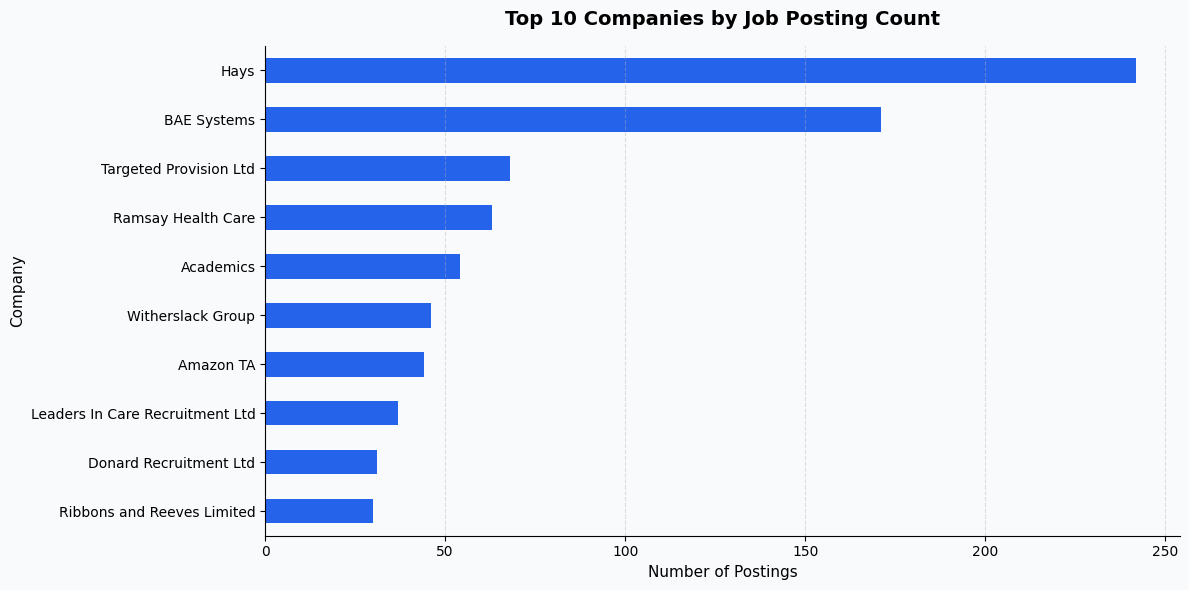

In [8]:
# plotting top 10 companies
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')

top_companies.sort_values().plot(kind='barh', ax=ax, color='#2563eb')

ax.set_title('Top 10 Companies by Job Posting Count', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Number of Postings', fontsize=11)
ax.set_ylabel('Company', fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='x', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('adzuna_top_companies.png', dpi=150, bbox_inches='tight')
plt.show()

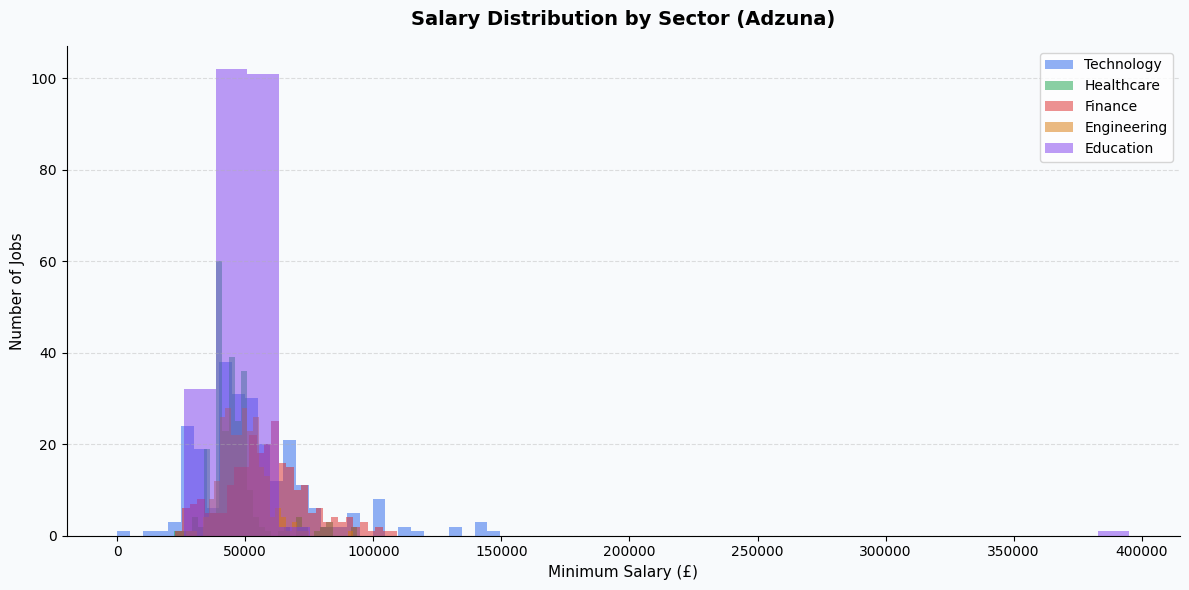

In [9]:
# salary distribution by sector
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#f8fafc')
ax.set_facecolor('#f8fafc')

colors = ['#2563eb', '#16a34a', '#dc2626', '#d97706', '#7c3aed']
sectors = df['sector'].unique()

for sector, color in zip(sectors, colors):
    data = df[df['sector'] == sector]['salary_min']
    data = data[data > 0]
    ax.hist(data, bins=30, alpha=0.5, label=sector, color=color)

ax.set_title('Salary Distribution by Sector (Adzuna)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Minimum Salary (£)', fontsize=11)
ax.set_ylabel('Number of Jobs', fontsize=11)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('adzuna_salary_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# key notes for sprint 2
print("key findings from Adzuna EDA:")
print("- 1250 jobs collected, 250 per sector - perfect")
print("- 99% of jobs have salary info - great for analysis")
print("- average salary: £51,500")
print("- descriptions capped at 500 chars by Adzuna API - ok for NLP")
print("- Hays dominates with 242 postings - recruitment agency")
print("- need to flag recruitment agencies vs direct employers in Sprint 2")

key findings from Adzuna EDA:
- 1250 jobs collected, 250 per sector - perfect
- 99% of jobs have salary info - great for analysis
- average salary: £51,500
- descriptions capped at 500 chars by Adzuna API - ok for NLP
- Hays dominates with 242 postings - recruitment agency
- need to flag recruitment agencies vs direct employers in Sprint 2
